<a href="https://colab.research.google.com/github/zhangyingchengqi/Modern-Computer-Vision-with-PyTorch/blob/master/Chapter03/Steps_to_build_a_neural_network_on_FashionMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 第三章 第五节 训练神经网络 steps to build a neural network on FashionMNIST

In [1]:
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
device = "cuda" if torch.cuda.is_available() else "cpu"
from torchvision import datasets
data_folder = '~/data/FMNIST' # This can be any directory you want to
# download FMNIST to
fmnist = datasets.FashionMNIST(data_folder, download=True, train=True)
tr_images = fmnist.data
tr_targets = fmnist.targets

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.3MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 210kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.90MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 13.7MB/s]


In [2]:
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float()  # 将输入张量 x 转换为浮点数类型（模型一般需要 float32 作为输入）
        # 将输入的图像数据展平成一维向量
        # Fashion-MNIST 原始是 28x28 的灰度图，这里把每张图片变成 (28*28 = 784) 的向量
        x = x.view(-1,28*28)
        self.x, self.y = x, y
    def __getitem__(self, ix):
        x, y = self.x[ix], self.y[ix]
        return x.to(device), y.to(device) # 同时把它们放到指定的计算设备上 (CPU 或 GPU)
    def __len__(self):
        return len(self.x)

In [3]:
def get_data():
    train = FMNISTDataset(tr_images, tr_targets)
    # 用 DataLoader 封装 Dataset
    # - batch_size=32: 每次取 32 张图片和对应标签，组成一个 batch
    # - shuffle=True: 每个 epoch 前都会打乱数据，避免模型记住顺序带来的偏差
    trn_dl = DataLoader(train, batch_size=32, shuffle=True)
    return trn_dl

In [4]:
from torch.optim import SGD
def get_model():
    model = nn.Sequential(
        nn.Linear(28 * 28, 1000),
        nn.ReLU(),
        nn.Linear(1000, 10)
    ).to(device)
    loss_fn = nn.CrossEntropyLoss()
    optimizer = SGD(model.parameters(), lr=1e-2)
    return model, loss_fn, optimizer

In [11]:
def train_batch(x, y, model, opt, loss_fn):
    # 设置模型为训练模式
    # （比如 dropout、batchnorm 在训练和测试时行为不同，这里启用训练模式）
    model.train() # <- let's hold on to this until we reach dropout section
    # call your model like any python function on your batch of inputs
    # 前向传播
    prediction = model(x)
    # compute loss
    batch_loss = loss_fn(prediction, y)
    # based on the forward pass in `model(x)` compute all the gradients of   'model.parameters()'
    batch_loss.backward()
    # apply new-weights = f(old-weights, old-weight-gradients) where  "f" is the optimizer
    # 更新参数：用优化器根据梯度更新模型参数
    # opt.step() 相当于执行 “新参数 = 旧参数 - 学习率 * 梯度”
    optimizer.step()
    # Flush gradients memory for next batch of calculations
    optimizer.zero_grad()
    # 返回当前 batch 的损失值（用 .item() 转成 Python float）
    return batch_loss.item()

总结执行流程

切换训练模式 → model.train()

前向传播 → prediction = model(x)

计算损失 → loss_fn(prediction, y)

反向传播 → .backward() 计算梯度

参数更新 → opt.step()

清零梯度 → opt.zero_grad()

返回损失值 → 方便监控训练情况

In [12]:
# 装饰器 @torch.no_grad()
# 禁用梯度计算，加快推理速度，节省显存（因为验证/测试不需要反向传播）
@torch.no_grad()
def accuracy(x, y, model):
    model.eval() # Sets the model to evaluation mode. In PyTorch, neural network modules (e.g., torch.nn.Module) have two modes:
    # training (model.train()) and evaluation (model.eval()).
    # Evaluation mode changes the behavior of certain layers, such as:
    #1. Dropout layers: Disabled, so no neurons are randomly dropped. (不再随机屏蔽神经元)
    #2. Batch normalization layers: Use running statistics (mean and variance训练过程中累积的全局统计值（running mean/var）)
    # instead of batch-specific statistics(当前 batch 的统计值).

    # get the prediction matrix for a tensor of `x` images 即前向传播
    prediction = model(x)
    # compute if the location of maximum in each row coincides with ground truth
    # 在预测结果矩阵的最后一个维度（类别维度）上取最大值
    # max(-1) 返回两个值：
    # - max_values: 每个样本预测的最大概率值（其实这里不太用）
    # - argmaxes: 每个样本预测的类别索引
    max_values, argmaxes = prediction.max(-1)
    # 比较预测类别 argmaxes 和真实标签 y
    # 得到一个布尔张量，True 表示预测正确，False 表示错误
    is_correct = argmaxes == y
    # 将布尔张量移动到 CPU，然后转为 NumPy 数组，再转为 Python 列表
    return is_correct.cpu().numpy().tolist()
# is_correct.cpu():Moves the tensor to the CPU (if it’s on a GPU).
#This is necessary because subsequent operations (like converting to NumPy) require the tensor to be on the CPU.

In [13]:
trn_dl = get_data()
model, loss_fn, optimizer = get_model()

In [9]:
losses, accuracies = [], []
# 用两个列表分别存储每个 epoch 的平均损失和准确率
# losses: [loss_epoch1, loss_epoch2, ...]
# accuracies: [acc_epoch1, acc_epoch2, ...]

for epoch in range(5):
    print(epoch)
    # 训练 5 个 epoch，每个 epoch 会完整遍历一次训练数据集

    epoch_losses, epoch_accuracies = [], []
    # 用来存储当前 epoch 中所有 batch 的损失值和正确率标记

    # --------------------- 训练部分 ---------------------
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch  # 从 DataLoader 中取出一个 batch 的数据和标签
        batch_loss = train_batch(x, y, model, optimizer, loss_fn)
        # 调用前面写好的 train_batch() 执行一次前向 + 反向传播 + 更新参数
        epoch_losses.append(batch_loss)
        # 保存这个 batch 的损失

    # 计算当前 epoch 的平均损失
    epoch_loss = np.array(epoch_losses).mean()

    # --------------------- 验证部分 ---------------------
    for ix, batch in enumerate(iter(trn_dl)):
        x, y = batch
        is_correct = accuracy(x, y, model)
        # 调用 accuracy() 函数，返回布尔列表，表示该 batch 中每个样本是否预测正确
        epoch_accuracies.extend(is_correct)
        # 把所有 batch 的结果拼接到一起，准备算整体准确率

    # 计算当前 epoch 的准确率（正确个数 / 总样本数）
    epoch_accuracy = np.mean(epoch_accuracies)

    # --------------------- 记录结果 ---------------------
    losses.append(epoch_loss)
    accuracies.append(epoch_accuracy)
    # 保存每个 epoch 的平均损失和准确率，后面可以画图或打印


0
1
2
3
4


/tmp/ipython-input-3821360026.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])


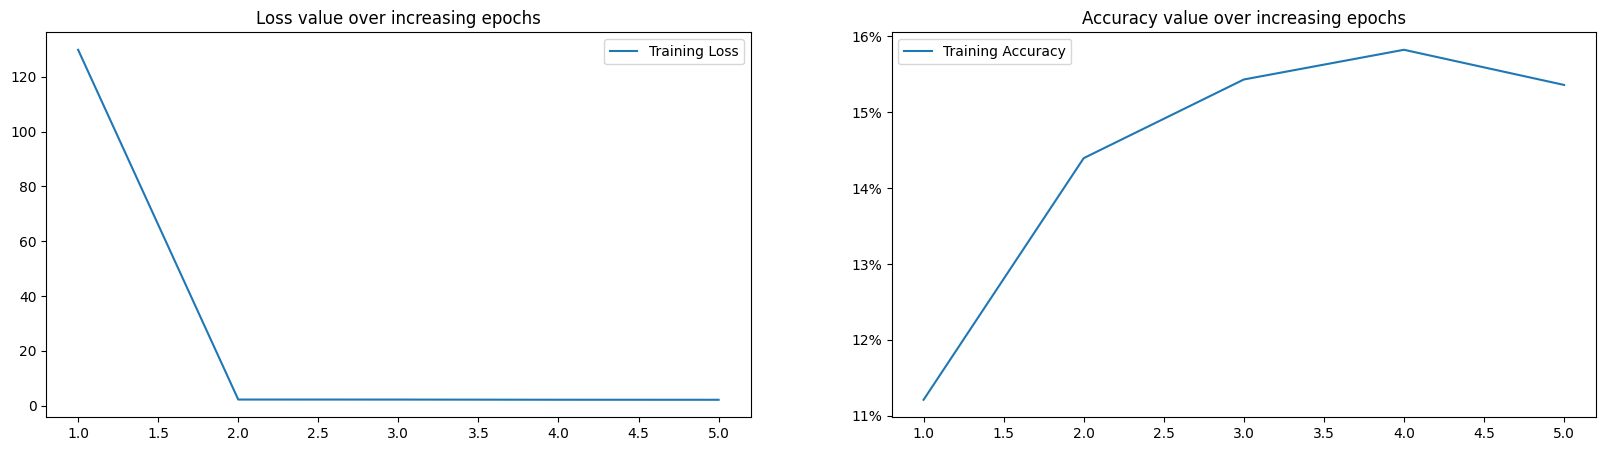

In [14]:
epochs = np.arange(5)+1
plt.figure(figsize=(20,5))
plt.subplot(121)
plt.title('Loss value over increasing epochs')
plt.plot(epochs, losses, label='Training Loss')
plt.legend()
plt.subplot(122)
plt.title('Accuracy value over increasing epochs')
plt.plot(epochs, accuracies, label='Training Accuracy')
# 把纵轴刻度转为百分比格式
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.legend()

# 第三章 第六节 缩放数据集以提升模型准确度  scalling the dataset